<h2>Creating a Machine Learning Model to Predict Presence of Kelp Species</h2>

<h4><strong>Data Used</strong></h4>
<ul>
    <li>Copernicus Marine Data</li><br>

| Dataset | CMEMS product ID| CMEMS product<br>description | Variable | Product User Manual |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|
| Baltic Sea Ocean Colour Plankton, Reflectances,<br>Transparency and Optics L3 NRT daily observations | OCEANCOLOUR_BAL_BGC_L3_NRT_009_131 | <a href="https://data.marine.copernicus.eu/product/OCEANCOLOUR_BAL_BGC_L3_NRT_009_131/description" target="_blank">Description</a> | Diffuse attenuation coefficient of light at 490 nm<br>(Kd490) | <a href="chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://documentation.marine.copernicus.eu/PUM/CMEMS-OC-PUM.pdf" target="_blank">User Manual</a> |
| Baltic Sea- Sea Surface Temperature Reprocessed | SST_BAL_SST_L4_REP_OBSERVATIONS_010_016 | <a href="https://data.marine.copernicus.eu/product/SST_BAL_SST_L4_REP_OBSERVATIONS_010_016/description" target="_blank">Description</a> | Sea Surface Temperature <br> (analysed_sst) | <a href="https://documentation.marine.copernicus.eu/PUM/CMEMS-SST-PUM-010-016-040.pdf" target="_blank">User Manual</a> |
</ul>
<ul>   
    <li>EMODnet Bathymetry</li><br>

| Dataset | EMODnet resource ID| Metadata |
|:--------------------:|:-----------------------:|:-------------:|
| EMODnet Bathymetry DTM |FR-330-715-368-00032-EMODnet-Bathy_Tile-Donwload|<a href="https://emodnet.ec.europa.eu/geonetwork/srv/eng/catalog.search#/metadata/b79b28b4-182b-4f5d-9cdb-b23fd216cfee" target="_blank">Link</a>|
</ul>

<ul>    
    <li>Wave Exposure</li><br>

| Dataset | Description | Metadata | 
|:--------------------:|:-----------------------:|:-------------:|
| Vågexponering | Data on relative wave exposure (m2s-1) based on wind speed and mean wind <br>direction. Data is available as a continuous grid and classified in EUNIS classes. | <a href="https://www.havochvatten.se/data-kartor-och-rapporter/data-och-statistik/havskatten/visa-datamangd.html?esc_entry=189&esc_context=public" target="_blank">Link</a> |
</ul>

<ul>
    <li>Presence/Absence of Kelp Species</li>

| Dataset | Description | Metadata | 
|:--------------------:|:-----------------------:|:-------------:|
| agg_kelp_raster.tif | A rasterized dataset of presence or absence of kelp species aggregated from <br>observational datasets over 9 years 2016-2024. Used as the dependent variable in modelling | <a href="https://www.smhi.se/data/hav-och-havsmiljo/datavardskap-oceanografi-och-marinbiologi/ladda-ner-data" target="_blank">Link</a> |
</ul>

<h4><strong>Learning Outcomes</strong></h4>

At the end of this notebook you will be able to:
* Access data via the Copernicus Marine Toolbox python API, reproject it and join it to various external datasets.
* Conduct an in-depth machine learning training and prediction methodology, including exploratory analysis, parameter hypertuning, and model selection.
* Generate a classified prediction dataset for kelp species along the swedish west coast.

<h4><strong>Outline</strong></h4>

This data product presents a machine learning approach to modelling the distribution of kelp habitat zones. Large perennial macroalgae such as kelp are important ecosystem components in shallow coastal ecosystems where they often form dense belts on hard substrates and provide a complex habitat for a large number of species. Increased nutrition load and a following decrease in Secchi depth in coastal areas is a threat that will limit the distribution of macroalgae communities to a shallower depth, decreasing the total area covered by these communities. The spatial distribution and cover of macroalgae communities is therefore subject to change over time and depends on environmental factors that can be monitored using RS data. The distribution of kelp habitat, including the large habitat forming kelp species Laminaria digitata, Laminaria hyperborea and Saccharina latissima was modelled using random forest classification. 

Kelp distribution is limited by environmental conditions such as light availability, seabed substrate, salinity and wave exposure. For spatial modelling and prediction of these species, raster layers of independent variables which cover the study area and have a spatial resolution which is fine enough for the spatial variation in heterogenic coastal environments are needed.  

## <a id='TOC_TOP'></a>Contents

</div>
    
 1. [Sea Surface Temperature](#section1)
 1. [Presence/Absence of Kelp Species](#section2)
 1. [Wave Exposure](#section3)
 1. [Bathymetry data](#section4)
 1. [Light Attenuation at 490nm](#section5)
 1. [Merging Datasets](#section3)
 1. [Machine Learning](#section4)
 1. [Model Validation and Model training](#section5)

<hr>

<div class="alert alert-block alert-warning"> 
  
#### Prerequisites:
 1. __*Wekeo account*__: Create an account via "Register" here: https://wekeo.copernicus.eu/
 2. __*Copernicus Marine*__ account: Create an account here: https://data.marine.copernicus.eu/register
 3. __*Five external libraries*__ must be installed in the wekeolab python environment. <br>
    -  open a *terminal* in the wekeolab JupyterHub environment
    -  activate the wekeolab environment <code style="background:red;color:white">conda activate wekeolab</code>
    -  execute the following commands to install the required packages in the wekeolab environment:
        -  <code style="background:red;color:white">conda install -c conda-forge xcube-cmems bottleneck openeo xgboost optuna hvplot geoviews -y</code> 


</div>

We start by importing all libraries that will be used in this notebook.

In [1]:
import pyproj
print(pyproj.datadir.get_data_dir())

# Copernicus Marine Toolbox data import
import copernicusmarine as cm
from xcube.core.dsio import open_cube
from xcube.core.geom import clip_dataset_by_geometry
from xcube.core.gridmapping import GridMapping
from xcube.core.resampling import resample_in_space

# File handling and data science
import copy
import os
import numpy as np
import xarray as xr
import rioxarray
import bottleneck
import pandas as pd
import seaborn as sns
import optuna
from scipy.spatial import cKDTree
from sklearn.model_selection import train_test_split,StratifiedKFold, KFold, cross_val_score,RepeatedStratifiedKFold
from sklearn.preprocessing import RobustScaler, KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score ,confusion_matrix,precision_score,recall_score,f1_score # Important metrics for evaluation 

# Geospatial data management
import cartopy.crs as ccrs  
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
import shapely

# Visualisations
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import hvplot.xarray # For creating more interactive maps and plots
import hvplot.pandas
import geoviews
from bokeh.plotting import show
from bokeh.models import Legend

# Other
from IPython.display import JSON
import warnings
warnings.filterwarnings('ignore')

/home/jovyan/DTO_conda/share/proj


We first need to provide our username and password from our free account on the Copernicus Marine website:

In [2]:
# write in your CMEMS username and password
user = "nbrautigam"
pwd = "Bading42!Bading42!"

cm.login(user, pwd)

File /home/jovyan/.copernicusmarine/.copernicusmarine-credentials already exists, overwrite it ? [y/N]:

  y


INFO - 2025-06-18T12:44:26Z - Credentials file stored in /home/jovyan/.copernicusmarine/.copernicusmarine-credentials.


True

<div class="alert alert-info" role="alert">
  
## 1.  Sea Surface Temperature


</div>

We are now ready to remotely access a data cube time series for the Sea Surface Temperature during the summer months (June 1-October 30).

In [5]:
ds = cm.open_dataset(
    dataset_id = 'DMI_BAL_SST_L4_REP_OBSERVATIONS_010_016',
    minimum_longitude = 10.7,
    maximum_longitude = 12.1,
    minimum_latitude = 57.3,
    maximum_latitude = 59,
    start_datetime = "2016-01-01",
    end_datetime = "2024-12-31",
    variables = ['analysed_sst']
)

ds

INFO - 2025-06-18T08:29:02Z - Selected dataset version: "202012"
INFO - 2025-06-18T08:29:02Z - Selected dataset part: "default"
WARNING - 2025-06-18T08:29:02Z - You are using the dataset DMI_BAL_SST_L4_REP_OBSERVATIONS_010_016, version '202012', part 'default'. This exact version and part of the dataset will be retired on the 2025-06-25T00:00:00.000Z. For more information you can check: https://marine.copernicus.eu/user-corner/product-roadmap/transition-information
WARNING - 2025-06-18T08:29:04Z - Some of your subset selection [2016-01-01 00:00:00+00:00, 2024-12-31 00:00:00+00:00] for the time dimension exceed the dataset coordinates [1982-01-01 00:00:00+00:00, 2023-12-31 00:00:00+00:00]


<xarray.Dataset> Size: 143MB
Dimensions:       (time: 2922, latitude: 86, longitude: 71)
Coordinates:
  * latitude      (latitude) float32 344B 57.3 57.32 57.34 ... 58.96 58.98 59.0
  * longitude     (longitude) float32 284B 10.7 10.72 10.74 ... 12.06 12.08 12.1
  * time          (time) datetime64[ns] 23kB 2016-01-01 ... 2023-12-31
Data variables:
    analysed_sst  (time, latitude, longitude) float64 143MB dask.array<chunksize=(2879, 16, 16), meta=np.ndarray>
Attributes:
    title:        Baltic Sea SST analysis, daily reprocessed level 4 analysis
    institution:  Danish Meteorological Institute, DMI
    history:      Version 1.0
    comment:      IN NO EVENT SHALL DMI OR ITS REPRESENTATIVES BE LIABLE FOR ...
    Conventions:  CF-1.4, Unidata Observation Dataset v1.0
    references:   Høyer, J. L. and She, J., Optimal interpolation of sea surf...
    source:       ESA SST CCI, C3S and  CMEMS FMI and SMHI Sea ice concentration

If you would like to change the geographic area please adjust the minimum and maximum latitude and longitude. If you would like to change the time scale please change the variables for "start_datetime" and "end_datetime" dates. After the data is loaded we take a look at the resulting data cube. We see that we have a 3D dataset comprised of 9 Years within a rectangular area. The only variable we have chosen to access at this time is analysed_sst. Note that the time series data cube is loaded in as a Dask array so that the full dataset is not loaded into server memory until data is manipulated in some way. This allows for much faster data loading, but if you attempt to access a very long time series the server can still be overloaded and crash!

Next, we only want data for the summer months (i.e June to October) and we will extract that data leveraging the time coordinate of xarray dataset 

In [6]:
ds = ds.sel(time=ds['time'].dt.month.isin([6, 10]))

<div class="alert alert-block alert-warning"> 
    Our goal is to get a static value of sea surface temperature for each latitude-longitude pair (pixel) in our dataset. As sea surface temperature (SST) does not show much variability over the years, we take the mean of SST for each pixel over the period of 9 years and plot the results. 
</div>

We will now read in some basic open source shapefiles of land and ocean surfaces to give our maps more context

In [8]:
land = shpreader.natural_earth('10m', 'cultural', 'admin_0_countries')
land = cfeature.ShapelyFeature(shpreader.Reader(land).geometries(), ccrs.PlateCarree(), edgecolor='black', facecolor='lightgray', lw=0.3)

ocean = shpreader.natural_earth('10m', 'physical', 'ocean')
ocean = cfeature.ShapelyFeature(shpreader.Reader(ocean).geometries(), ccrs.PlateCarree(), edgecolor='none', facecolor='lightblue')

Our goal is to get a static value of sea surface temperature for each latitude-longitude pair (pixel) in our dataset. As sea surface temperature (SST) does not show much variability over the years, we take the mean of SST for each pixel over the period of 9 years and plot the results. We will now convert kelvin to celsius and plot the 9 year summer mean of sea surface temperature in region of interest (ROI)

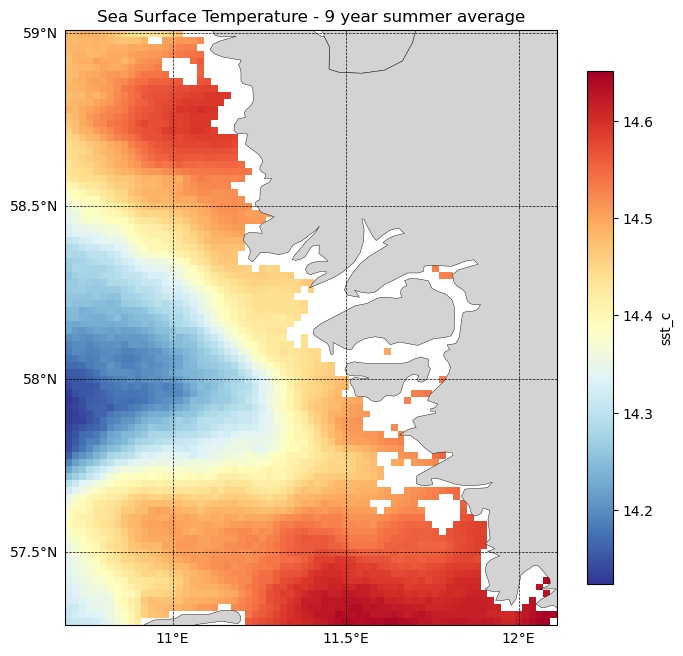

In [9]:
ds = ds.assign(sst_c=ds['analysed_sst']-273.15)

mean_sst = ds['sst_c'].mean(dim='time').to_dataset(name='sst_c')

fig, axis = plt.subplots(1,1,figsize=(7,7),subplot_kw=dict(projection=ccrs.PlateCarree()))

plot=mean_sst.sst_c.plot(
    ax=axis,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    cbar_kwargs={'orientation':'vertical', 'shrink':0.8},
)

axis.add_feature(land, zorder=1)

g1 = axis.gridlines(draw_labels=True, zorder=2, color='0.0', linestyle='--',linewidth=0.5)
g1.top_labels = False
g1.right_labels = False
g1.xlocator = mticker.FixedLocator(np.arange(10, 14, 0.5))
g1.ylocator = mticker.FixedLocator(np.arange(55, 60, 0.5))

axis.set_title('Sea Surface Temperature - 9 year summer average')
plt.tight_layout()

From the above results, we are confident that our early assumption of very less variability of sea surface temperature is correct, as we can see that it ranges between 14 amd 14.6 C. over our ROI

We will plot the null and non-null values of sea surface temperature as null values might indicate land or coastal areas 

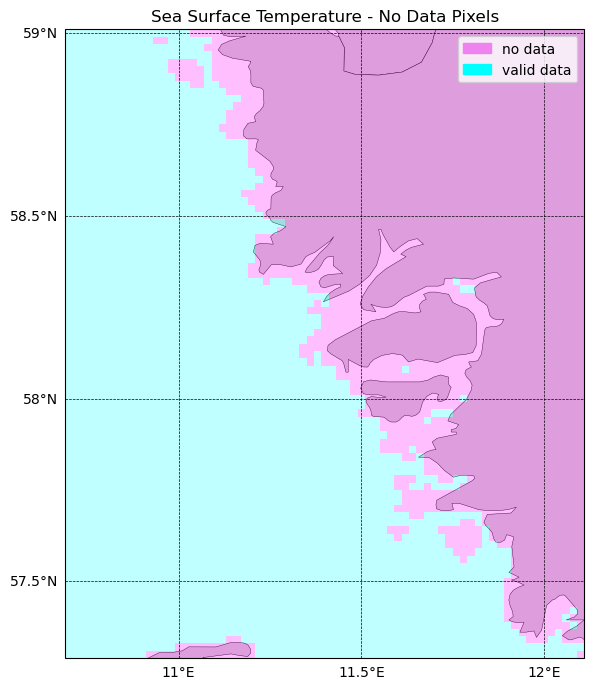

In [10]:
always_nan = ds['sst_c'].isnull().sum(dim='time')

fig, axis = plt.subplots(1,1,figsize=(7,7),subplot_kw=dict(projection=ccrs.PlateCarree()))

plot=always_nan.plot(
    ax=axis,
    transform=ccrs.PlateCarree(),
    zorder=2,
    cmap='cool',
    alpha=0.25,
    add_colorbar=False,
#    cbar_kwargs={'orientation':'vertical', 'shrink':0.8},
)

axis.add_feature(land, zorder=1)

g1 = axis.gridlines(draw_labels=True, zorder=2, color='0.0', linestyle='--',linewidth=0.5)
g1.top_labels = False
g1.right_labels = False
g1.xlocator = mticker.FixedLocator(np.arange(10, 14, 0.5))
g1.ylocator = mticker.FixedLocator(np.arange(55, 60, 0.5))

no_data = mpatches.Patch(color='violet', label='no data')
data = mpatches.Patch(color='cyan', label='valid data')

plt.legend(handles=[no_data, data])

axis.set_title('Sea Surface Temperature - No Data Pixels')
plt.tight_layout()

<div class="alert alert-info" role="alert">
  
## 2.  Presence/Absence of Kelp Species 


</div>

In the following code, we will now read in our Presence/Absence of Kelp Species (dependent variable) for our ROI which is provided with our repository in Raster format using rioxarray, reproject it to EPSG:4326, convert it into a xarray dataset, rename the required variable for further ease and fill null values which are intially filled with -2 as buffer value for this dataset to actual nan values

In [12]:
# Pulling in prepared raster data from agg_kelp_raster.tif file 
kelp_ras = os.path.join('external_data', 'agg_kelp_raster.tif')

# Opening the .tif file using rioxaraay
kelp_da = rioxarray.open_rasterio(kelp_ras)

# Reprojecting the data in .tif file back to latitude and longitude (EPSG:4326)
kelp_da=kelp_da.rio.reproject("EPSG:4326")

# Covert our xarray.DataArray into a xarray.Dataset
kelp_ds = kelp_da.to_dataset('band')

# Rename the variable to a more useful name
kelp_ds = kelp_ds.rename({1: 'kelp'})
 
#nodata = np.nan
kelp_ds = xr.where(kelp_ds == 2, np.nan, kelp_ds)
 
kelp_ds

<xarray.Dataset> Size: 17MB
Dimensions:      (y: 1688, x: 1284)
Coordinates:
  * x            (x) float64 10kB 10.68 10.68 10.68 10.68 ... 12.7 12.7 12.7
  * y            (y) float64 14kB 59.01 59.0 59.0 59.0 ... 56.34 56.34 56.34
    spatial_ref  int64 8B 0
Data variables:
    kelp         (y, x) float64 17MB nan nan nan nan nan ... nan nan nan nan nan

As we can see that, our longitude and latitude coordinates are represented by 'x' and 'y' respectively. So, we will rename these to longitude and latitude for further ease in the following code

In [13]:
kelp_ds=kelp_ds.rename({'x':'longitude','y':'latitude'}) # Run Once
kelp_ds

<xarray.Dataset> Size: 17MB
Dimensions:      (latitude: 1688, longitude: 1284)
Coordinates:
  * longitude    (longitude) float64 10kB 10.68 10.68 10.68 ... 12.7 12.7 12.7
  * latitude     (latitude) float64 14kB 59.01 59.0 59.0 ... 56.34 56.34 56.34
    spatial_ref  int64 8B 0
Data variables:
    kelp         (latitude, longitude) float64 17MB nan nan nan ... nan nan nan

If not already in our ROI, we will spatially clip the spatial location to our desired latitude and longitude from the following code and plot the results 

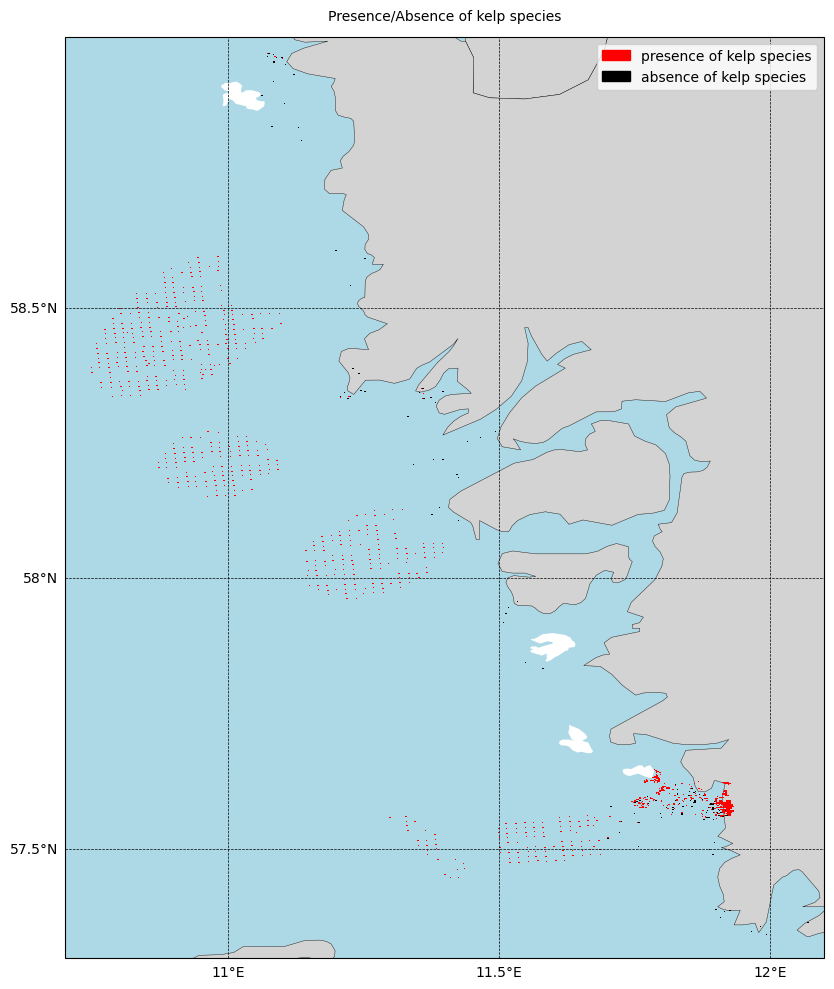

In [15]:
fig, axis = plt.subplots(1,1,figsize=(10,10),subplot_kw=dict(projection=ccrs.PlateCarree()))

plot = kelp_ds.kelp.plot(
    ax=axis,
    transform=ccrs.PlateCarree(),
    zorder=2,
    cmap='flag',
    add_colorbar=False,
)

axis.add_feature(land, zorder=1)
axis.add_feature(ocean,zorder=0)

g1 = axis.gridlines(draw_labels=True, zorder=2, color='0.0', linestyle='--',linewidth=0.5)
g1.top_labels = False
g1.right_labels = False
g1.xlocator = mticker.FixedLocator(np.arange(10, 14, 0.5))
g1.ylocator = mticker.FixedLocator(np.arange(55, 60, 0.5))

pres = mpatches.Patch(color='red', label='presence of kelp species')
abse = mpatches.Patch(color='black', label='absence of kelp species')

plt.legend(handles=[pres, abse])

plt.title('Presence/Absence of kelp species', fontsize=10, pad=12)

plt.tight_layout()

<div class="alert alert-block alert-warning"> 
    Now, our task is to merge our sea surface temperature with our data representing presence/absence of kelp species so that we can find out the relationship between them but before that, there are a set of preliminary steps we need to perform before merging two xarray datasets
    
1. __*Checking if both datasets have same coordinate reference system and coordinate names.*__
2. __*Checking if both have different shape or not (resolution).*__
3. __*Create grid maps for both target and source dataset.*__
4. __*Resample source dataset to target dataset's shape and resolution.*__ 
5. __*Checking again if both datasets have the same resolution and have been resampled correctly.*__
  
</div>

    
    

    

In [16]:
# Checking if both datasets have same coordinate reference system and coordinate names before further operations
print(kelp_ds.rio.crs)
print(mean_sst.rio.crs)
print(mean_sst.coords)
print(kelp_ds.coords)
# Checking if both have different shape or not (resolution)
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(mean_sst['sst_c'].shape)
print(mean_sst['sst_c'].dims)

# Create grid maps for both kelp_ds dataset and mean_sst
kelp_ds_gm = GridMapping.from_dataset(kelp_ds)
mean_sst_gm = GridMapping.from_dataset(mean_sst)

# check grid coords for sea surface temperature and kelp species presence/absence (dependent variable)
x_coords_kelp, y_coords_kelp = kelp_ds_gm.xy_coords
x_coords_sst, y_coords_sst = mean_sst_gm.xy_coords

# Resample mean_sst to kelp_ds resolution and gridding
mean_sst_resampled = resample_in_space(mean_sst, source_gm=mean_sst_gm, target_gm=kelp_ds_gm)

# Checking again if both datasets have the same resolution and have been resampled correctly 
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(mean_sst_resampled['sst_c'].shape)
print(mean_sst_resampled['sst_c'].dims)

None
None
Coordinates:
  * latitude   (latitude) float32 344B 57.3 57.32 57.34 ... 58.96 58.98 59.0
  * longitude  (longitude) float32 284B 10.7 10.72 10.74 ... 12.06 12.08 12.1
Coordinates:
  * longitude    (longitude) float64 7kB 10.7 10.7 10.7 10.71 ... 12.1 12.1 12.1
  * latitude     (latitude) float64 9kB 59.0 59.0 59.0 58.99 ... 57.3 57.3 57.3
    spatial_ref  int64 8B 0
(1076, 886)
('latitude', 'longitude')
(86, 71)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')


Now, as we have successfully resampled both datasets to same resolution and shape. 
    
These set of techniques will be used for our other independent variables as we move forward

<div class="alert alert-info" role="alert">
  
## 3.  Wave Exposure 


</div>

We will now pull in wave exposure data for our area of interest. 

Because this data set is too large to include in the GitHub repository, it must be downloaded from Hav och Vatten myndigheten at this website: https://www.havochvatten.se/data-kartor-och-rapporter/data-och-statistik/havskatten/visa-datamangd.html?esc_entry=189&esc_context=public

The data that should be used is the continuous raster data rather than the reclassified data, and ideally the dataset should be clipped to the area of interest in a GIS program in order to not overload the WEkEO server.

In [17]:
# Pulling in prepared raster data from external_data/SWM_NMD_WGS84.tif file 
wave_exposure_ras = os.path.join('external_data', 'SWM_NMD_WGS84.tif') 

# Opening the .tif file using rioxaraay
wave_exposure_da = rioxarray.open_rasterio(wave_exposure_ras,chunks={'x':512, 'y':512})

# Reprojecting the data in .tif file back to latitude and longitude (EPSG:4326)
wave_exposure_da=wave_exposure_da.rio.reproject("EPSG:4326")

# Covert our xarray.DataArray into a xarray.Dataset
wave_exposure_ds = wave_exposure_da.to_dataset('band')

wave_exposure_ds = wave_exposure_ds.rename({1: 'wave_exposure'})
wave_exposure_ds = xr.where(wave_exposure_ds == -3.4028235e+38, np.nan, wave_exposure_ds)

wave_exposure_ds=wave_exposure_ds.rename({'x':'longitude','y':'latitude'})

print(kelp_ds.rio.crs)
print(wave_exposure_ds.rio.crs)
print(wave_exposure_ds.coords)
print(kelp_ds.coords)

# Checking if both have different shape or not (resolution)
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(wave_exposure_ds['wave_exposure'].shape)
print(wave_exposure_ds['wave_exposure'].dims)

# Spatial clipping to kelp_ds dataset so that only region of interest is further analyzed
wave_exposure_ds = wave_exposure_ds.sel(latitude=slice(59,57.3), longitude=slice(10.7,12.1)) 

wave_exposure_ds_gm = GridMapping.from_dataset(wave_exposure_ds)
wave_exposure_ds_resampled = resample_in_space(wave_exposure_ds, source_gm=wave_exposure_ds_gm, target_gm=kelp_ds_gm)

# Checking again if both datasets have the same resolution and have been resampled correctly 
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(wave_exposure_ds_resampled['wave_exposure'].shape)
print(wave_exposure_ds_resampled['wave_exposure'].dims)

None
None
Coordinates:
  * longitude    (longitude) float64 154kB 9.748 9.748 9.748 ... 12.29 12.29
  * latitude     (latitude) float64 131kB 59.25 59.25 59.25 ... 57.1 57.1 57.1
    spatial_ref  int64 8B 0
Coordinates:
  * longitude    (longitude) float64 7kB 10.7 10.7 10.7 10.71 ... 12.1 12.1 12.1
  * latitude     (latitude) float64 9kB 59.0 59.0 59.0 58.99 ... 57.3 57.3 57.3
    spatial_ref  int64 8B 0
(1076, 886)
('latitude', 'longitude')
(16313, 19293)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')


<div class="alert alert-info" role="alert">
    
## 4.  Bathymetry data 


</div>

We will now pull in bathymetry data provided in the GitHub repository for our area of interest. 

In [18]:
# Pulling in prepared raster data from external_data/Area of interest_220222.tif file 
bathymetry_ras = os.path.join('external_data', 'Area of interest_220222.tif')

# Opening the .tif file using rioxaraay
bathymetry_da = rioxarray.open_rasterio(bathymetry_ras,chunks={'x':512, 'y':512})

# Reprojecting the data in .tif file back to latitude and longitude (EPSG:4326)
bathymetry_da=bathymetry_da.rio.reproject("EPSG:4326")

# Covert our xarray.DataArray into a xarray.Dataset
bathymetry_ds = bathymetry_da.to_dataset('band')

bathymetry_ds = bathymetry_ds.rename({1: 'bathymetry'})

bathymetry_ds=bathymetry_ds.rename({'x':'longitude','y':'latitude'})

print(kelp_ds.rio.crs)
print(bathymetry_ds.rio.crs)
print(bathymetry_ds.coords)
print(kelp_ds.coords)

# Checking if both have different shape or not (resolution)
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(bathymetry_ds['bathymetry'].shape)
print(bathymetry_ds['bathymetry'].dims)

# Spatial clipping to kelp_ds dataset so that only region of interest is further analyzed
bathymetry_ds = bathymetry_ds.sel(latitude=slice(59,57.3), longitude=slice(10.7,12.1)) 

bathymetry_ds_gm = GridMapping.from_dataset(bathymetry_ds)
bathymetry_ds_resampled = resample_in_space(bathymetry_ds, source_gm=bathymetry_ds_gm, target_gm=kelp_ds_gm)

# Checking again if both datasets have the same resolution and have been resampled correctly 
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(bathymetry_ds_resampled['bathymetry'].shape)
print(bathymetry_ds_resampled['bathymetry'].dims)

None
EPSG:4326
Coordinates:
  * longitude    (longitude) float64 16kB 10.04 10.04 10.04 ... 12.12 12.13
  * latitude     (latitude) float64 16kB 59.21 59.2 59.2 ... 57.17 57.17 57.17
    spatial_ref  int64 8B 0
Coordinates:
  * longitude    (longitude) float64 7kB 10.7 10.7 10.7 10.71 ... 12.1 12.1 12.1
  * latitude     (latitude) float64 9kB 59.0 59.0 59.0 58.99 ... 57.3 57.3 57.3
    spatial_ref  int64 8B 0
(1076, 886)
('latitude', 'longitude')
(1957, 2006)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')


<div class="alert alert-info" role="alert">
    
## 5.  Light Attenuation at 490nm


</div>

We will now calculate the euphotic zone depth as derived in the "Euphotic Zone" notebook and take the mean depth value during summer months.

In [19]:
id_zeu='cmems_obs-oc_bal_bgc-transp_my_l3-olci-300m_P1D'
varbs_zeu = ['KD490']

ds_zeu = cm.open_dataset(
    dataset_id = id_zeu,
    minimum_longitude = 10.7,
    maximum_longitude = 12.1,
    minimum_latitude = 57.3,
    maximum_latitude = 59,
    start_datetime = "2016-01-01",
    end_datetime = "2024-12-31",
    variables = varbs_zeu
)

def summer(month):
    return (month >= 6) & (month <= 10)

summer_ds = ds_zeu.sel(time=summer(ds_zeu['time.month']))
summer_ds_fill = summer_ds.ffill(dim='time', limit=None) # Forward Fill

summer_zeu = summer_ds_fill.mean(dim='time', skipna=True)

print("kelp_ds CRS:", kelp_ds.rio.crs)
print("summer_zeu CRS:", summer_zeu.rio.crs)
print("kelp_ds coords:", kelp_ds.coords)
print("summer_zeu coords:", summer_zeu.coords)

# Checking if both have different shape or not (resolution)
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(summer_zeu['KD490'].shape)
print(summer_zeu['KD490'].dims)

# Grid Mapping for KD490 and kelp dataset 
summer_zeu_gm = GridMapping.from_dataset(summer_zeu)
summer_zeu_resampled = resample_in_space(summer_zeu, source_gm=summer_zeu_gm, target_gm=kelp_ds_gm)

# Checking again if both datasets have the same resolution and have been resampled correctly 
print(kelp_ds['kelp'].shape)
print(kelp_ds['kelp'].dims)
print(summer_zeu_resampled['KD490'].shape)
print(summer_zeu_resampled['KD490'].dims)

INFO - 2025-06-18T08:51:27Z - Selected dataset version: "202211"
INFO - 2025-06-18T08:51:27Z - Selected dataset part: "default"
WARNING - 2025-06-18T08:51:31Z - Some of your subset selection [2016-01-01 00:00:00+00:00, 2024-12-31 00:00:00+00:00] for the time dimension exceed the dataset coordinates [2016-04-26 00:00:00+00:00, 2025-06-10 00:00:00+00:00]


kelp_ds CRS: None
summer_zeu CRS: None
kelp_ds coords: Coordinates:
  * longitude    (longitude) float64 7kB 10.7 10.7 10.7 10.71 ... 12.1 12.1 12.1
  * latitude     (latitude) float64 9kB 59.0 59.0 59.0 58.99 ... 57.3 57.3 57.3
    spatial_ref  int64 8B 0
summer_zeu coords: Coordinates:
  * latitude   (latitude) float32 3kB 57.3 57.3 57.31 57.31 ... 58.99 59.0 59.0
  * longitude  (longitude) float32 1kB 10.7 10.71 10.72 ... 12.09 12.09 12.1
(1076, 886)
('latitude', 'longitude')
(631, 263)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')
(1076, 886)
('latitude', 'longitude')


We have successfully spatially resampled all our independent variables to our dependent variables' shape and resolution for merging them later.

We can still not merge datasets yet because all the datasets have different latitude and longitude values even though being explicitly close to one another. During merging, values like 59.00001 and 59.00002 will be considered different. This will result in several null values for each latitude and longitude pair for different independent variables. 
    
##### There are two major techniques that we can do to mitigate such situations:
- Rounding off latitude and longitude values (to 4 decimal places or more to minimize loss of spatial information)
- Interpolating latitude and longitude values to another dataset's latitude and longitude values using Linear method, if you want you can pass different methods such as nearest, cubic, spline etc. (dependent variable dataset)

##### For this task, we will go forward with interploation of all independent variable's datasets to dependent variable's dataset to prevent loss of spatial information  


In [20]:
# Interpolate to have values for a particular xarray dataset latitude and longitude

# Interpolating wave exposure data to kelp dataset
if not (
    kelp_ds.latitude.equals(wave_exposure_ds_resampled.latitude) and
    kelp_ds.longitude.equals(wave_exposure_ds_resampled.longitude)
):
    print('Starting interpolation for wave exposure data')
    wave_exposure_ds_resampled = wave_exposure_ds_resampled.interp(latitude=kelp_ds.latitude, longitude=kelp_ds.longitude)

# Interpolating bathymetry data to kelp dataset
if not (
    kelp_ds.latitude.equals(bathymetry_ds_resampled.latitude) and
    kelp_ds.longitude.equals(bathymetry_ds_resampled.longitude)
):
    print('Starting interpolation for bathymetry data')
    bathymetry_ds_resampled = bathymetry_ds_resampled.interp(latitude=kelp_ds.latitude, longitude=kelp_ds.longitude)

# Interpolating sea surface temperature data to kelp dataset
if not (
    kelp_ds.latitude.equals(mean_sst_resampled.latitude) and
    kelp_ds.longitude.equals(mean_sst_resampled.longitude)
):
    print('Starting interpolation for sea surface temperature data')
    mean_sst_resampled = mean_sst_resampled.interp(latitude=kelp_ds.latitude, longitude=kelp_ds.longitude)

# Interpolating light attenuation coefficient data to kelp dataset
if not (
    kelp_ds.latitude.equals(summer_zeu_resampled.latitude) and
    kelp_ds.longitude.equals(summer_zeu_resampled.longitude)
):
    print('Starting interpolation for Diffusion attenuation coefficient data')
    summer_zeu_resampled = summer_zeu_resampled.interp(latitude=kelp_ds.latitude, longitude=kelp_ds.longitude)


Starting interpolation for wave exposure data
Starting interpolation for bathymetry data
Starting interpolation for sea surface temperature data
Starting interpolation for Diffusion attenuation coefficient data


Now, all our datasets are aligned, spatially in the same resolution, with interpolated latitude longitude values for ease of independent variables to be merged with dependent variables 

<div class="alert alert-info" role="alert">
  
## 6.  Merging Datasets


</div>

We will now combine all of our datasets into a single data array

In [21]:
# Combine all datasets 
combined = xr.merge([
    kelp_ds,
    mean_sst_resampled,
    wave_exposure_ds_resampled,
    bathymetry_ds_resampled,
    summer_zeu_resampled,
])

After all our datasets have been merged, they will be loaded in dask arrays and need to be converted into float arrays which we will perform with the help of compute function in the following code. 

In [22]:
combined=combined.compute() # Convert dask arrays back to float array in the xarray dataset

Now, we can play with the different methods on the combined dataset to explore the number of null values, unique values of each feature and much more etc. To view all the outputs without being truncated to a certain number, you might be required to run the uncommented code in the next cell.

In [ ]:
#original_threshold = np.get_printoptions()['threshold']
#print(original_threshold)
#np.set_printoptions(threshold=np.inf) 

In [28]:
print(combined.isnull().sum()) # Prints count of all null values of in all the features
#print((np.unique(combined['wave_exposure'].values))) # Prints all the unique values in the wave_exposure feature of the combined dataset
#print((np.unique(combined['bathymetry'].values))) # Prints all the unique values in the bathymetry feature of the combined dataset
#print((np.unique(combined['sst_c'].values))) # Prints all the unique values in the sea surface temperature feature of the combined dataset
#print((np.unique(combined['KD490'].values))) # Prints all the unique values in the Diffusion attenuation coefficient feature of the combined dataset

<xarray.Dataset> Size: 56B
Dimensions:        ()
Coordinates:
    spatial_ref    int64 8B 0
Data variables:
    kelp           int64 8B 951176
    sst_c          int64 8B 484638
    crs            int64 8B 0
    wave_exposure  int64 8B 597938
    bathymetry     int64 8B 0
    KD490          int64 8B 369600


After analysing the results from the above code, we see that wave exposure have some corrupt values which are not valid from a geospatial point and should be converted back to null values for prevention of error which is exactly what we do in the following code.

In [29]:
combined['wave_exposure'] = combined['wave_exposure'].where(combined['wave_exposure'] > 0, np.nan) # Converting corrupt values to nan 

<div class="alert alert-block alert-warning"> 
    When dealing with geospatial data, we assume that spatially close locations will have similar properties that is of those of it's neighbors and that becomes the basis of filling null values in the geospatial data. 
    
#### There are several techniques that we can do to mitigate such situations:
- Nearest Neighbor interpolation
- Spline Interpolation
- Kriging interpolation
- Inverse Distance Weighting interpolation

#### Most common method for filling null values is Inverse Distance Weighting interpolation and we will proceed with that for this purpose

**Inverse Distance Weighting (IDW)** is a deterministic spatial interpolation method used to estimate unknown values at unsampled locations based on the values of nearby known points. It assumes that closer points have more influence on the estimated value than distant ones — mathematically, the weight decreases with the inverse of the distance (typically raised to a power, often 2).

The estimated value at a location $ x_0 $ using IDW is:

$$
\hat{Z}(x_0) = \frac{\sum_{i=1}^{N} w_i(x_0) \cdot Z(x_i)}{\sum_{i=1}^{N} w_i(x_0)}
$$

Where the weights $ w_i(x_0) $ are defined as:

$$
w_i(x_0) = \frac{1}{d(x_0, x_i)^p}
$$

- $ Z(x_i) $: known value at location $ x_i $
- $ d(x_0, x_i) $: distance between target $ x_0 $ and known point $ x_i $
- $ p $: power parameter (commonly $ p = 2 $)
- $ N $: number of known points used

</div>



In [30]:
def idw_interpolation_2d_array(da, power=2, k=4):
    if power < 0:
        raise ValueError("The 'power' parameter for IDW should be non-negative.")
    if k <= 0:
        raise ValueError("The 'k' parameter (number of neighbors) must be positive.")
    if len(da.dims) != 2:
        raise ValueError("This function is for 2D DataArrays.")

    lat_dim, lon_dim = da.dims[0], da.dims[1]
    lon_coords, lat_coords = np.meshgrid(da[lon_dim].values, da[lat_dim].values, indexing='xy')
    all_points_grid = np.column_stack([lat_coords.ravel(), lon_coords.ravel()])
    valid_mask = ~np.isnan(da.values)

    if not np.any(valid_mask):
        return da.copy()

    valid_lat_coords = lat_coords[valid_mask]
    valid_lon_coords = lon_coords[valid_mask]
    valid_points = np.column_stack([valid_lat_coords, valid_lon_coords])
    valid_values = da.values[valid_mask]
    tree = cKDTree(valid_points)
    distances, idxs = tree.query(all_points_grid, k=k)
    interpolated_values = da.values.copy().ravel()
    nan_points_flat_idx = np.where(np.isnan(interpolated_values))[0]

    if nan_points_flat_idx.size > 0:
        nan_distances = distances[nan_points_flat_idx]
        nan_idxs = idxs[nan_points_flat_idx]
        for j, flat_idx in enumerate(nan_points_flat_idx):
            current_neighbors_idxs = nan_idxs[j]
            current_neighbors_distances = nan_distances[j]
            valid_neighbor_mask = (current_neighbors_idxs != -1)
            filtered_idxs = current_neighbors_idxs[valid_neighbor_mask]
            filtered_distances = current_neighbors_distances[valid_neighbor_mask]

            if filtered_idxs.size > 0:
                if np.any(filtered_distances == 0):
                    exact_match_idx = filtered_idxs[filtered_distances == 0][0]
                    interpolated_values[flat_idx] = valid_values[exact_match_idx]
                else:
                    weights = 1 / (filtered_distances ** power)
                    weights /= np.sum(weights)
                    interpolated_values[flat_idx] = np.sum(valid_values[filtered_idxs] * weights)
            else:
                interpolated_values[flat_idx] = np.nan

    final_data = interpolated_values.reshape(da.shape)
    return xr.DataArray(final_data, coords=da.coords, dims=da.dims, attrs=da.attrs)

In [31]:
# Filling Nan values with IDW interpolation
combined['wave_exposure']=idw_interpolation_2d_array(combined['wave_exposure']) 
combined['KD490']=idw_interpolation_2d_array(combined['KD490'])

After filling the null values in both wave exposure and diffusion attenuation coefficient at 490nm, you might check that we still have null values in sea surfce temperature and wonder why we didn't fill them using Inverse distance weighting because if we do so, then the null values which are representing coastal and land surfaces might get wrongly filled with IDW technique.

<div class="alert alert-info" role="alert">

## 7.  Machine Learning 
</div>

Now, we will proceed with the Machine Learning aspect of this notebook and for the easy handling of the data, we will convert our xarray dataset to Pandas Dataframe

In [32]:
pandas_df=combined.to_dataframe().reset_index() # Conversion of xarray dataset to pandas dataframe 

For the extraction of training data, we will drop all the data where our kelp label indicating presence/absence of kelp species is a null value

In [33]:
train_df=pandas_df.dropna(subset=['kelp']) # Drop rows where dependent_variable kelp is nan (null values)

<div class="alert alert-block alert-warning"> 
    Exploratory Data Analysis (EDA) refers to the preliminary steps before any kind of feature engineering, data manipulations, etc just to have a look how are features (columns) are looking and how are they related. Some Common pandas methods for EDA are:
    
- **info()** - Gives us an overview of datatypes, null values and non-null values for each feature 
- **corr()** - Tells us about the correlation of features with each other and dependent variable (Low correlation with the dependent variable is desired)
- **isnull().sum()** - Sum of null values in all the features
- **duplicated()** -  Shows duplicate rows (Duplication should be removed)
- **describe()** - Tells us about the count, minimum values, maximum values, standard deviation and percentiles of how data is distributed

##### We can also plot different types of charts and maps to get a better overview the features  
  
</div>

In [41]:
print(train_df.info()) # Check the datatype and count of null values in all the features 
print(train_df.corr()) # Almost all are weakly correlated with the dependent variable which is a good thing for the model 
print(train_df.isnull().sum()) # Sum of null values in all the features
print(len(train_df[train_df.duplicated()])) # Number of duplicate rows 
print(train_df.describe()) # Numerical statistics about each feature in the dataframe

<class 'pandas.core.frame.DataFrame'>
Index: 2160 entries, 17069 to 929347
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       2160 non-null   float64
 1   longitude      2160 non-null   float64
 2   kelp           2160 non-null   float64
 3   spatial_ref    2160 non-null   int64  
 4   sst_c          1260 non-null   float64
 5   crs            2160 non-null   int64  
 6   wave_exposure  2160 non-null   float64
 7   bathymetry     2160 non-null   float64
 8   KD490          2160 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 168.8 KB
None
               latitude  longitude      kelp  spatial_ref     sst_c  crs  \
latitude       1.000000  -0.904757 -0.069901          NaN -0.489803  NaN   
longitude     -0.904757   1.000000  0.222010          NaN  0.648693  NaN   
kelp          -0.069901   0.222010  1.000000          NaN  0.273573  NaN   
spatial_ref         NaN        NaN       NaN    

In [42]:
print(train_df['crs'].unique()) # Checking the unique values in 'crs' feature
print(train_df['spatial_ref'].unique()) # Checking the unique values in 'spatial_ref' feature 

[0]
[0]


In [43]:
pd.options.plotting.backend = 'holoviews'

train_df.hvplot.hist(y='wave_exposure', bins=100, title='Wave Exposure in ROI Histogram')

:Histogram   [wave_exposure]   (Count)

In [44]:
train_df.hvplot.hist(y='sst_c', bins=100, title='Sea Surface Temperature in ROI Histogram')

:Histogram   [sst_c]   (Count)

<div class="alert alert-block alert-warning"> 
    
1. From the above EDA, we see that we have two unwanted columns: 'crs' and 'spatial_ref' providing no information which should be removed before modelling as it might lead to increase in noise during modelling.
2. We create a feature engineering function for our train dataset which will do the following:
   - Drop 'crs' and 'spatial_ref' columns
   - Create a new feature which will indicate the null values in sea surface temeperature (Binary encoding)
   - Convert float values of dependent variable (kelp) into integer
   - Create a new feature from Diffusion attenuation coefficient which gives us Zeu Depth
   - Drop 'KD490' variable as it will be highly correlated with 'Zeu Depth'
   - Take log of the values of wave exposure feature as they are very large and have a lot of variance which might introduce a bias for the model that greater values should be given more importance
</div>

In [46]:
def feature_engineering_train(df):
    df=df.drop(['crs','spatial_ref'],axis=1)
    df['sst_missing'] = df['sst_c'].isna().astype(int) # Convert missing values of analysed_sst into a separate feature (binary encoding)
    df['kelp'] = df['kelp'].astype(int) # Conversion from float values to int values for binary classification 
    df['Zeu_depth']=6.8/df['KD490']
    df=df.drop('KD490',axis=1) # Run once 
    df['wave_exposure']=np.log1p(df['wave_exposure']) # High Variance values create bias in feature selection so taking log values for wave exposure feature 
    return df

In [47]:
train_df = feature_engineering_train(train_df)

Separating the independent and dependent features from the dataset for validation, eventual modelling and training

In [48]:
X=train_df.drop('kelp',axis=1) # Separating independent variables from dataset
y=train_df['kelp'] # separating dependent variables from dataset

<div class="alert alert-info" role="alert">
  
## 8. Model Validation  and  Model training
</div>

Scaling is essential for linear models like linear regression, logistic regression, neural networks, SVC but not required for ensemble methods. If you want to experiment with linear model or models which require scaling, Uncomment the below code and proceed

In [32]:
# Robust Scaler
# def scaling_function(train_df,test_df):
#     rbs=RobustScaler()
#     train_df[['wave_exposure','bathymetry','Zeu_depth']]=rbs.fit_transform(train_df[['wave_exposure','bathymetry','Zeu_depth']])
#     test_df[['wave_exposure','bathymetry','Zeu_depth']]=rbs.transform(test_df[['wave_exposure','bathymetry','Zeu_depth']])
#     return train_df,test_df

Now, we introduce a new concept in feature engineering called Binning in which we convert numerical variables into categorical variables and we roll back to our previous question of not filling null values in the feature Sea surface temperature. In this, we will fill the sea surface temperature with a buffer value which is -1 in this case and convert non null values into categorical values (0, 1, 2... ).

In [55]:
# Fill NaNs with sentinel value (e.g., -1) to safely apply discretization
X_train_filled = X.copy()
nan_mask = X_train_filled['sst_c'].isna()
X_train_filled['sst_c'] = X_train_filled['sst_c'].fillna(-1)

# Fit discretizer on non-NaN values
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
discretizer.fit(X_train_filled.loc[~nan_mask, ['sst_c']])

# Apply transformation to non-NaN values
X_train_filled.loc[~nan_mask, 'sst_c'] = discretizer.transform(X_train_filled.loc[~nan_mask, ['sst_c']]).flatten()
X_train_filled

,latitude,longitude,sst_c,wave_exposure,bathymetry,sst_missing,Zeu_depth
17069,58.968933,11.071635,-1.0,13.161815,-84.413534,1,21.156346
17070,58.968933,11.073215,-1.0,13.136454,-41.711856,1,24.063168
17071,58.968933,11.074795,-1.0,13.026834,-8.354340,1,27.896001
17072,58.968933,11.076375,-1.0,11.484210,3.815782,1,27.321214
17962,58.967353,11.082695,-1.0,10.555170,-6.896867,1,21.856294
...,...,...,...,...,...,...,...
921365,57.357313,11.981726,-1.0,11.417582,-4.776112,1,49.186544
921366,57.357313,11.983306,-1.0,11.390318,-0.695803,1,58.517197
925785,57.349413,11.965926,-1.0,11.191170,-8.123678,1,45.806242
929346,57.343093,11.992787,-1.0,12.415556,-8.408744,1,53.971599


After all these feature engineering steps, data manipulations and ploting of data, our data is finally ready for the training of the model for preliminary validation 

<div class="alert alert-block alert-warning"> 
    
**For the preliminary validation of different models, we have chosen the following models**

- Gradient Boosting Classifier
- Random Forest Classifier
- Extra Trees Classifier
- XG Boosting classifier
- Adaptive Boosting Classifier
- Logistic Regression

**Also, we plot the feature importances of these models to see which feature is contributing most to the model prediction.**
</div>

Random Forest Classifier accuracy : 0.9421296296296297
Gradient boosting Classifier accuracy : 0.9328703703703703
Extra trees Classifier accuracy : 0.9560185185185185
XG boosting Classifier accuracy : 0.9351851851851852
Adaptive boosting Classifier accuracy : 0.9143518518518519
Logistic Regression Classifier accuracy : 0.8865740740740741
------------------------------------------------------------
Random Forest Classifier accuracy : 0.9537037037037037
Gradient boosting Classifier accuracy : 0.9375
Extra trees Classifier accuracy : 0.9421296296296297
XG boosting Classifier accuracy : 0.9490740740740741
Adaptive boosting Classifier accuracy : 0.9212962962962963
Logistic Regression Classifier accuracy : 0.8981481481481481
------------------------------------------------------------
Random Forest Classifier accuracy : 0.9398148148148148
Gradient boosting Classifier accuracy : 0.9490740740740741
Extra trees Classifier accuracy : 0.9490740740740741
XG boosting Classifier accuracy : 0.9467592

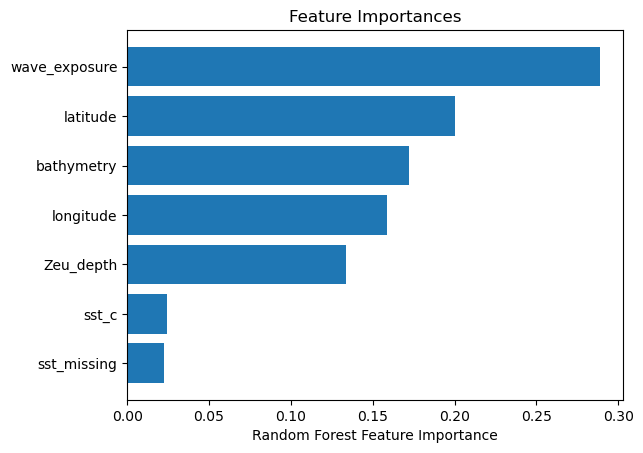

------------------------------------------------------------
------------------------------------------------------------
Gradient Boosting Average accuracy 0.9371913580246913
Gradient Boosting Average f1 score 0.7294203133231284


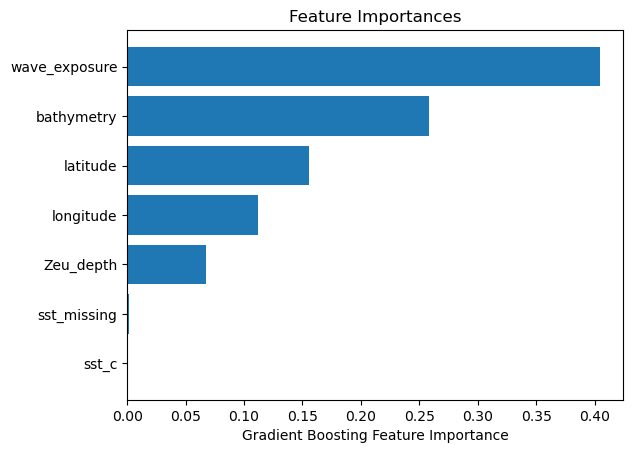

------------------------------------------------------------
------------------------------------------------------------
Extra trees Average accuracy 0.9464506172839506
Extra trees Average f1 score 0.7763911608224522


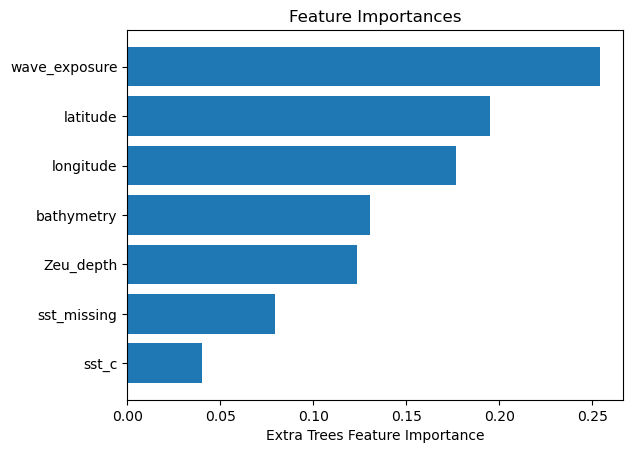

------------------------------------------------------------
------------------------------------------------------------
XG boosting Average accuracy 0.940895061728395
XG boosting Average f1 score 0.7581999554986781


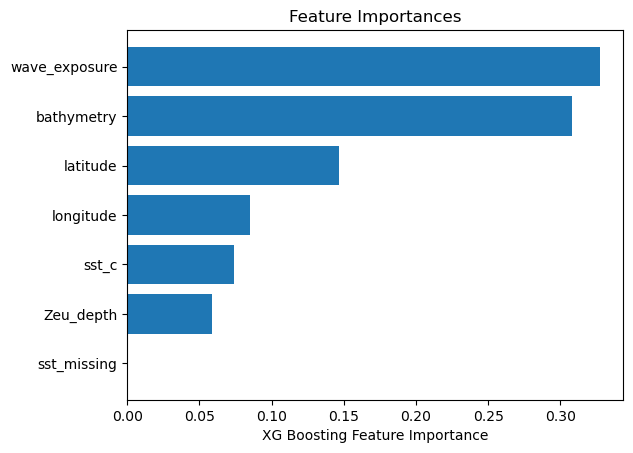

------------------------------------------------------------
------------------------------------------------------------
Adaptive boosting classifier Average accuracy 0.9231481481481479
Adaptive boosting classifier Average f1 score 0.6500251573453296


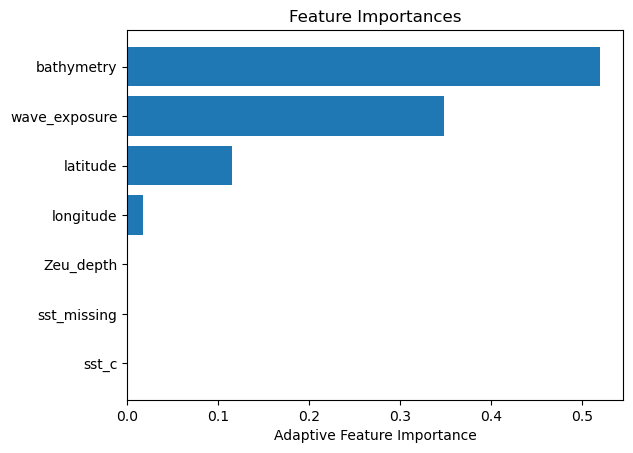

------------------------------------------------------------

------------------------------------------------------------
Logistic Regression Average accuracy 0.9043
Logistic Regression Average f1 score 0.5502
------------------------------------------------------------


In [59]:
# Validation of different models 

# Tree Based Models 

# Gradient Boosting classifier

scores_gb=[]
f1_gb=[]

# Random Forest Classifier

scores_forest=[]
f1_forest=[]

# Extra Trees Classifier

scores_et=[]
f1_et=[]

# XG Boosting classifier

f1_xg=[]
scores_xg = []

# Adaptive Boosting Classifier

f1_ada=[]
scores_ada = []

# Logistic Regression

scores_lr=[]
f1_lr=[]

skf = RepeatedStratifiedKFold(n_splits=5,n_repeats=3)
for train, test in skf.split(X_train_filled, y):
    model_forest = RandomForestClassifier()
    model_forest.fit(X_train_filled.iloc[train],y.iloc[train])
    y_pred_forest=model_forest.predict(X_train_filled.iloc[test])
    acc=accuracy_score(y.iloc[test],y_pred_forest)
    f1_score_forest=f1_score(y.iloc[test],y_pred_forest)
    f1_forest.append(f1_score_forest)
    scores_forest.append(acc)
    print(f'Random Forest Classifier accuracy : {acc}')
    

    model_gb = GradientBoostingClassifier()
    model_gb.fit(X_train_filled.iloc[train],y.iloc[train])
    y_pred_gb=model_gb.predict(X_train_filled.iloc[test])
    acc_gb=accuracy_score(y.iloc[test],y_pred_gb)
    f1_score_gb=f1_score(y.iloc[test],y_pred_gb)
    f1_gb.append(f1_score_gb)
    scores_gb.append(acc_gb)
    print(f'Gradient boosting Classifier accuracy : {acc_gb}')
    
        

    model_et = ExtraTreesClassifier()
    model_et.fit(X_train_filled.iloc[train],y.iloc[train])
    y_pred_et=model_et.predict(X_train_filled.iloc[test])
    acc_et=accuracy_score(y.iloc[test],y_pred_et)
    f1_score_et=f1_score(y.iloc[test],y_pred_et)
    f1_et.append(f1_score_et)
    scores_et.append(acc_et)
    print(f'Extra trees Classifier accuracy : {acc_et}')
    

    model_xg = XGBClassifier()
    model_xg.fit(X_train_filled.iloc[train],y.iloc[train])
    y_pred_xg=model_xg.predict(X_train_filled.iloc[test])
    acc_xg=accuracy_score(y.iloc[test],y_pred_xg)
    f1_score_xg=f1_score(y.iloc[test],y_pred_xg)
    f1_xg.append(f1_score_xg)
    scores_xg.append(acc_xg)
    print(f'XG boosting Classifier accuracy : {acc_xg}')
    

    model_ada = AdaBoostClassifier()
    model_ada.fit(X_train_filled.iloc[train],y.iloc[train])
    y_pred_ada=model_ada.predict(X_train_filled.iloc[test])
    acc_ada=accuracy_score(y.iloc[test],y_pred_ada)
    f1_score_ada=f1_score(y.iloc[test],y_pred_ada)
    f1_ada.append(f1_score_ada)
    scores_ada.append(acc_ada)
    print(f'Adaptive boosting Classifier accuracy : {acc_ada}')

    
    model_lr = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
    model_lr.fit(X_train_filled.iloc[train],y.iloc[train])
    y_pred_lr = model_lr.predict(X_train_filled.iloc[test])
    acc_lr = accuracy_score(y.iloc[test],y_pred_lr)
    f1_score_lr = f1_score(y.iloc[test], y_pred_lr)
    f1_lr.append(f1_score_lr)
    scores_lr.append(acc_lr)
    print(f'Logistic Regression Classifier accuracy : {acc_lr}')
    
    print("-"*60)
  
print("-"*60)
print(f"Random forest Average accuracy {np.mean(scores_forest)}")
print(f"Random forest Average f1 score {np.mean(f1_forest)}")

importances_forest = model_forest.feature_importances_
idxs = np.argsort(importances_forest)
plt.title('Feature Importances')
plt.barh(range(len(idxs)), importances_forest[idxs], align='center')
plt.yticks(range(len(idxs)), [X.columns[i] for i in idxs])
plt.xlabel('Random Forest Feature Importance')
plt.show()


print("-"*60)
print("-"*60)
print(f"Gradient Boosting Average accuracy {np.mean(scores_gb)}")
print(f"Gradient Boosting Average f1 score {np.mean(f1_gb)}")
importances_gb = model_gb.feature_importances_
idxs = np.argsort(importances_gb)
plt.title('Feature Importances')
plt.barh(range(len(idxs)), importances_gb[idxs], align='center')
plt.yticks(range(len(idxs)), [X.columns[i] for i in idxs])
plt.xlabel('Gradient Boosting Feature Importance')
plt.show()

print("-"*60)
print("-"*60)
print(f"Extra trees Average accuracy {np.mean(scores_et)}")
print(f"Extra trees Average f1 score {np.mean(f1_et)}")
importances_et = model_et.feature_importances_
idxs = np.argsort(importances_et)
plt.title('Feature Importances')
plt.barh(range(len(idxs)), importances_et[idxs], align='center')
plt.yticks(range(len(idxs)), [X.columns[i] for i in idxs])
plt.xlabel('Extra Trees Feature Importance')
plt.show()
print("-"*60)

print("-"*60)
print(f"XG boosting Average accuracy {np.mean(scores_xg)}")
print(f"XG boosting Average f1 score {np.mean(f1_xg)}")
importances_xg = model_xg.feature_importances_
idxs = np.argsort(importances_xg)
plt.title('Feature Importances')
plt.barh(range(len(idxs)), importances_xg[idxs], align='center')
plt.yticks(range(len(idxs)), [X.columns[i] for i in idxs])
plt.xlabel('XG Boosting Feature Importance')
plt.show()
print("-"*60)
print("-"*60)
print(f"Adaptive boosting classifier Average accuracy {np.mean(scores_ada)}")
print(f"Adaptive boosting classifier Average f1 score {np.mean(f1_ada)}")
importances_ada = model_ada.feature_importances_
idxs = np.argsort(importances_ada)
plt.title('Feature Importances')
plt.barh(range(len(idxs)), importances_ada[idxs], align='center')
plt.yticks(range(len(idxs)), [X.columns[i] for i in idxs])
plt.xlabel('Adaptive Feature Importance')
plt.show()
print("-"*60)

print("\n" + "-"*60)
print(f"Logistic Regression Average accuracy {np.mean(scores_lr):.4f}")
print(f"Logistic Regression Average f1 score {np.mean(f1_lr):.4f}")
print("-"*60)


<div class="alert alert-block alert-warning"> 
    
**From this preliminary validation, we got our top performing models**

- Random Forest Classifier
- XG Boosting classifier


**Also, we saw the feature importances of these models and realized that most important independent variables for this binary classification task are usually _Wave Exposure_ and _bathymetry_**
</div>

Now, we proceed to the final part of the ML pipeline which is pulling in the test data and training the model on the full training data and finding the best hyperparameters for that model using Optuna

In [60]:
# Test data 
test_df = pandas_df.copy()
test_df=test_df[test_df['kelp'].isna()] # These are the rows where we have to predict the presence and absence of kelp species given the independent variables

Creating a similar function which we created for feature engineering of test data except in this there is no integer conversion of float values of kelp feature as that needs to be predicted

In [63]:
def feature_engineering_test(df):
    df=df.drop(['crs','spatial_ref'],axis=1)
    df['sst_missing'] = df['sst_c'].isna().astype(int) # Convert missing values of analysed_sst into a separate feature (binary encoding)
    df['Zeu_depth']=6.8/df['KD490']
    df=df.drop('KD490',axis=1)
    df['wave_exposure']=np.log1p(df['wave_exposure'])
    return df

In [64]:
test_df=feature_engineering_test(test_df)

In [65]:
X_test=test_df.drop('kelp',axis=1) # Dropping dependent variable which needs to be predicted after training and hyperparameter tuning

In [39]:
# Scaling if using linear models as explained in validation 
# X_train_filled,test_df=scaling_function(X_train_filled,test_df)

<div class="alert alert-block alert-warning">     

Transforming the test data's sea surface temperature with Binning technique which we have implemented earlier with the training data.

- **NOTE** - We will not fit our test data here, we will just transform the test data with the same fitted training data
</div>

In [72]:
X_test_filled = X_test.copy()
nan_mask_test = X_test_filled['sst_c'].isna()
X_test_filled['sst_c'] = X_test_filled['sst_c'].fillna(-1)

X_test_filled.loc[~nan_mask_test, 'sst_c'] = discretizer.transform(X_test_filled.loc[~nan_mask_test, ['sst_c']]).flatten()

<div class="alert alert-block alert-warning"> 
    
**Now, we will move to the hyperparameter tuning and modelling for different parameters for both XGBoost and RandomForestClassifier to analyse which parameters are best for this model and will be best for predictions**
- We will use Optuna library for Hyperparameter tuning
- All the Hyperparameters and their respective range can be found in their respective documentation for more extensive experimentation
  - [XGBoost Docs](https://xgboost.readthedocs.io/en/stable/parameter.html)
  - [Random Forest Classifier Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)
- In Optuna, we create a study and pass an objective function to it having different allowed values of hyperparameters which returns a metric which should be either maximized or minimized 

</div>

In [73]:
def objective(trial):
    n_splits = 5
    n_repeats = 3
    cv_strategy = RepeatedStratifiedKFold(
        n_splits=n_splits, n_repeats=n_repeats, random_state=42
    )

    classifier_name = trial.suggest_categorical("classifier", ["RandomForest","XGBoost"])

    if classifier_name == "RandomForest":
        rf_max_depth = trial.suggest_int("rf_max_depth", 2, 64, log=True)
        rf_n_estimators = trial.suggest_int("rf_n_estimators", 10, 300)
        rf_criterion=trial.suggest_categorical("rf_criterion", ["gini", "entropy", "log_loss"])
        rf_max_features=trial.suggest_categorical("rf_max_features",["sqrt", "log2", None])
        classifier_obj = RandomForestClassifier(
            max_depth=rf_max_depth, n_estimators=rf_n_estimators, criterion=rf_criterion,max_features=rf_max_features, random_state=42
        )
        classifier_to_evaluate = classifier_obj 
        
    elif classifier_name == "XGBoost":
        xgb_n_estimators = trial.suggest_int("xgb_n_estimators", 50, 1000)
        xgb_max_depth = trial.suggest_int("xgb_max_depth", 3, 10)
        xgb_learning_rate = trial.suggest_float("xgb_learning_rate", 0.1, 0.3)
        xgb_subsample = trial.suggest_float("xgb_subsample", 0.5, 1.0)
        xgb_colsample_bytree = trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0)
        xgb_gamma = trial.suggest_float("xgb_gamma", 0.0, 0.5)
        xgb_reg_alpha = trial.suggest_float("xgb_reg_alpha", 1e-5, 1.0, log=True) # L1 regularization
        xgb_reg_lambda = trial.suggest_float("xgb_reg_lambda", 1e-5, 1.0, log=True) # L2 regularization

        classifier_obj = XGBClassifier(
            n_estimators=xgb_n_estimators, 
            max_depth=xgb_max_depth,
            learning_rate=xgb_learning_rate,
            subsample=xgb_subsample,
            colsample_bytree=xgb_colsample_bytree,
            gamma=xgb_gamma,
            reg_alpha=xgb_reg_alpha,
            reg_lambda=xgb_reg_lambda,
            random_state=42,
        )
        classifier_to_evaluate = classifier_obj
        

    
    fold_accuracies = []
    fold_f1_scores = []


    for train_idx, test_idx in cv_strategy.split(X_train_filled, y):
        X_train_fold, X_test_fold = X_train_filled.iloc[train_idx], X_train_filled.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

        # Fit the classifier (or pipeline) on the training fold
        classifier_to_evaluate.fit(X_train_fold, y_train_fold)

        # Make predictions on the test fold
        y_pred_fold = classifier_to_evaluate.predict(X_test_fold)

        # Calculate metrics for the current fold
        acc = accuracy_score(y_test_fold, y_pred_fold)
        f1 = f1_score(y_test_fold, y_pred_fold) # Or 'macro' if classes are balanced and you want equal weight

        fold_accuracies.append(acc)
        fold_f1_scores.append(f1)

    # Average the metrics across all folds
    mean_accuracy = np.mean(fold_accuracies)
    mean_f1_score = np.mean(fold_f1_scores)

    #  Report the primary metric (F1-score in this case) to Optuna
    trial.set_user_attr("mean_accuracy", mean_accuracy) # Store accuracy as user attribute

    return mean_f1_score # Return the F1-score for Optuna to optimize


  
After finding out the best set of parameters and the best model, we can fit our entire training data using those parameters and predict on our entire test data


In [74]:
# Got these parameters from the above hyperparameter tuning code
model_for_predictions=RandomForestClassifier(
    max_depth=28,       #40
    n_estimators=111,   #175
    criterion="entropy",
    max_features=None)

model_for_predictions.fit(X_train_filled,y)

,n_estimators,111
,criterion,'entropy'
,max_depth,28
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
final_y=model_for_predictions.predict(X_test_filled)

  
Create a new feature for our test data storing predictions which can used for further plotting and creation of maps


In [76]:
X_test_filled['predictions']=final_y

   
Creating a CSV file from the final dataframe having predictions and storing it in results directory to be used later for plotting purposes


In [77]:
output_directory = os.path.join(os.getcwd(), 'results')
os.makedirs(output_directory, exist_ok=True) # Creates dir if it doesn't exist
output_filepath = os.path.join(output_directory, 'model_results.csv')
X_test_filled.to_csv(output_filepath)
print(f"Results saved to: {output_filepath}")

Results saved to: /home/jovyan/results/model_results.csv
